# Regime-style diagnostics on `prices.csv`

This notebook explores whether the **public** price history shows shifts in volatility, correlation, or factor structure—similar conventions as `months_validate.py` (30 ticks/day, 252 trading days/year). **Per-sector** views use `meta.sector_id` (same order as asset columns A00…A24).

**Note:** Quiet historical data does not rule out a **new** regime in live simulation. Use this as descriptive evidence plus your sliding-month Sharpe runs.

In [29]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from submission import STRATEGY_REGISTRY, load_meta, load_prices
from months_validate import evaluate_sliding_month_sharpes, sliding_month_groups_shape

# Match months_validate.py / competition runtime
N_ASSETS = 25
TICKS_PER_DAY = 30
TRADING_DAYS_PER_YEAR = 252
TRADING_DAYS_PER_MONTH = TRADING_DAYS_PER_YEAR // 12
TICKS_PER_MONTH = TRADING_DAYS_PER_MONTH * TICKS_PER_DAY

## Load data

In [30]:
prices = load_prices()
meta = load_meta()

assert prices.shape[1] == N_ASSETS
n_ticks = prices.shape[0]
n_days_full = n_ticks // TICKS_PER_DAY
n_months_full = n_ticks // TICKS_PER_MONTH

print(f"Ticks: {n_ticks:,}, trading days: {n_days_full}, ~full months: {n_months_full}")
print(f"Meta: {len(meta.spread_bps)} assets (static; no time dimension)")

Ticks: 37,800, trading days: 1260, ~full months: 60
Meta: 25 assets (static; no time dimension)


## Daily log returns (sum of tick log-returns within each day)

In [31]:
logp = np.log(prices)
lr_tick = np.diff(logp, axis=0)

n_days = lr_tick.shape[0] // TICKS_PER_DAY
trim = n_days * TICKS_PER_DAY
lr_day = (
    lr_tick[:trim].reshape(n_days, TICKS_PER_DAY, N_ASSETS).sum(axis=1)
)

ew_daily = lr_day.mean(axis=1)

def ann_vol(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return float("nan")
    return float(np.std(x, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR))


def ann_sharpe(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    mu, sd = float(np.mean(x)), float(np.std(x, ddof=1))
    if sd < 1e-12:
        return float("nan")
    return np.sqrt(TRADING_DAYS_PER_YEAR) * mu / sd


def avg_pairwise_corr(R: np.ndarray) -> float:
    """R shape (n_days_window, n_assets)."""
    if R.shape[0] < 3:
        return float("nan")
    C = np.corrcoef(R.T)
    iu = np.triu_indices_from(C, k=1)
    return float(np.mean(C[iu]))


print(f"Daily return matrix: {lr_day.shape[0]} days × {lr_day.shape[1]} assets")

Daily return matrix: 1259 days × 25 assets


## Full sample vs first half vs second half (equal-weight market)

In [32]:
h = n_days // 2
segments = {
    "full": slice(None),
    "1st half": slice(0, h),
    "2nd half": slice(h, None),
}

rows = []
for name, sl in segments.items():
    e = ew_daily[sl]
    rows.append(
        {
            "segment": name,
            "days": len(e),
            "mean_daily_ew": float(np.mean(e)),
            "ann_vol_ew": ann_vol(e),
            "ann_Sharpe_ew": ann_sharpe(e),
            "avg_pairwise_corr": avg_pairwise_corr(lr_day[sl]),
        }
    )

summary = pd.DataFrame(rows).set_index("segment")
display(summary)

r1, r2 = summary.loc["1st half", "ann_vol_ew"], summary.loc["2nd half", "ann_vol_ew"]
if np.isfinite(r1) and r1 > 0:
    print(f"Second / first half EW ann. vol ratio: {r2 / r1:.4f}")

,days,mean_daily_ew,ann_vol_ew,ann_Sharpe_ew,avg_pairwise_corr
segment,,,,,
full,1259,0.000406,0.154177,0.664369,0.228316
1st half,629,0.000652,0.149285,1.100331,0.220432
2nd half,630,0.000161,0.158935,0.256056,0.235629


Second / first half EW ann. vol ratio: 1.0646


## Per-month equal-weight volatility (competition "month" = 21 days)

,month_index,ann_vol_ew
count,59.000000,59.000000
mean,29.000000,0.152494
std,17.175564,0.031278
min,0.000000,0.094658
25%,14.500000,0.128378
50%,29.000000,0.150014
75%,43.500000,0.173492
max,58.000000,0.238668


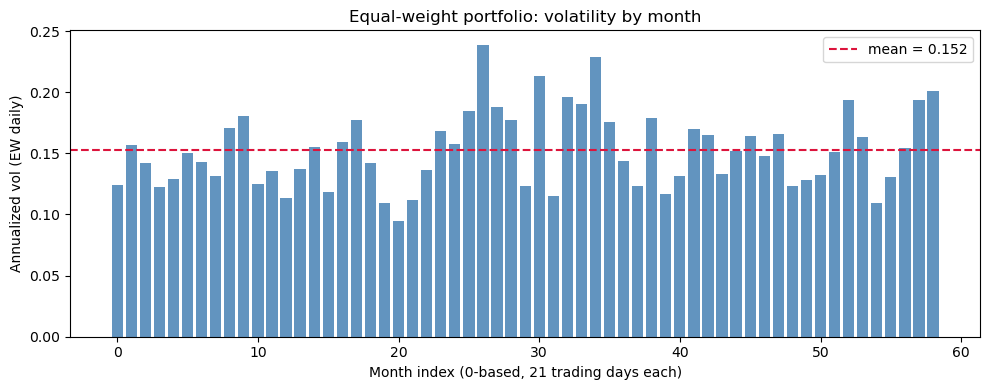

In [33]:
dpm = TRADING_DAYS_PER_MONTH
n_months = n_days // dpm
month_labels = []
month_vol_ew = []
for m in range(n_months):
    sl = slice(m * dpm, (m + 1) * dpm)
    r_m = lr_day[sl].mean(axis=1)
    month_labels.append(m)
    month_vol_ew.append(ann_vol(r_m))

month_vol_ew = np.array(month_vol_ew)
month_df = pd.DataFrame({"month_index": month_labels, "ann_vol_ew": month_vol_ew})
display(month_df.describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_df["month_index"], month_df["ann_vol_ew"], color="steelblue", alpha=0.85)
ax.axhline(month_vol_ew.mean(), color="crimson", ls="--", label=f"mean = {month_vol_ew.mean():.3f}")
ax.set_xlabel("Month index (0-based, 21 trading days each)")
ax.set_ylabel("Annualized vol (EW daily)")
ax.set_title("Equal-weight portfolio: volatility by month")
ax.legend()
plt.tight_layout()
plt.show()

## Per-sector diagnostics (`meta.sector_id`)

Each asset column in `prices` matches a row in `meta.csv` (A00…A24). We treat **equal-weight within sector** as the sector return series, and **average pairwise correlation among assets in that sector** as within-sector co-movement. If a **sector-specific** regime changed in the sample, you often see a **persistent** shift in that sector’s vol or within-sector correlation vs other sectors—not just a single noisy month.

Assets per sector:
  sector 0: 5 assets
  sector 1: 5 assets
  sector 2: 5 assets
  sector 3: 5 assets
  sector 4: 5 assets


segment,1st half,2nd half,2nd/1st vol ratio
sector,,,
0,0.1814,0.1896,1.0454
1,0.1753,0.1890,1.0779
2,0.1790,0.1901,1.0617
3,0.2018,0.2033,1.0074
4,0.1874,0.1997,1.0658


segment,1st half,2nd half,delta corr (2nd−1st)
sector,,,
0,0.2309,0.2497,0.0187
1,0.1551,0.1673,0.0122
2,0.2166,0.2324,0.0158
3,0.2915,0.2802,-0.0113
4,0.2270,0.2599,0.0329


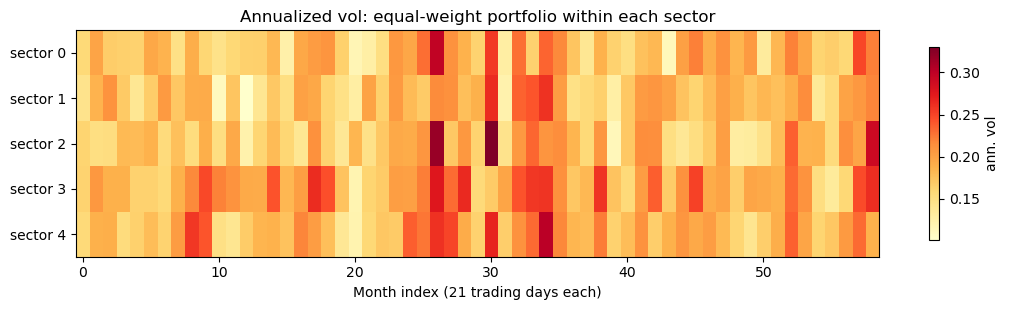

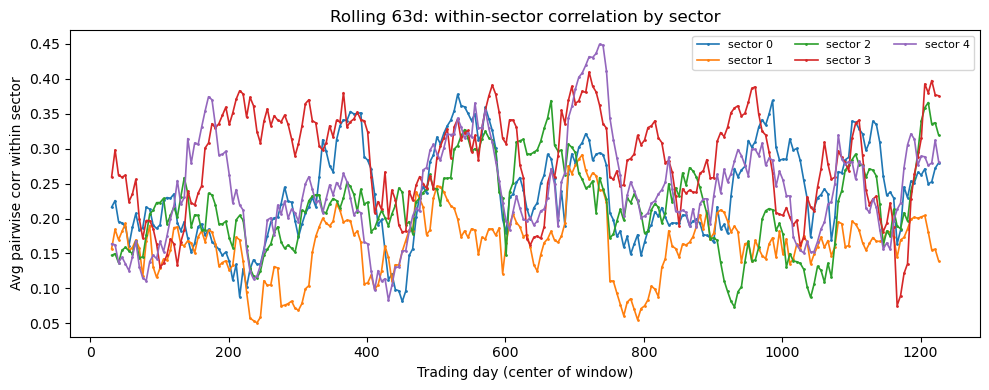

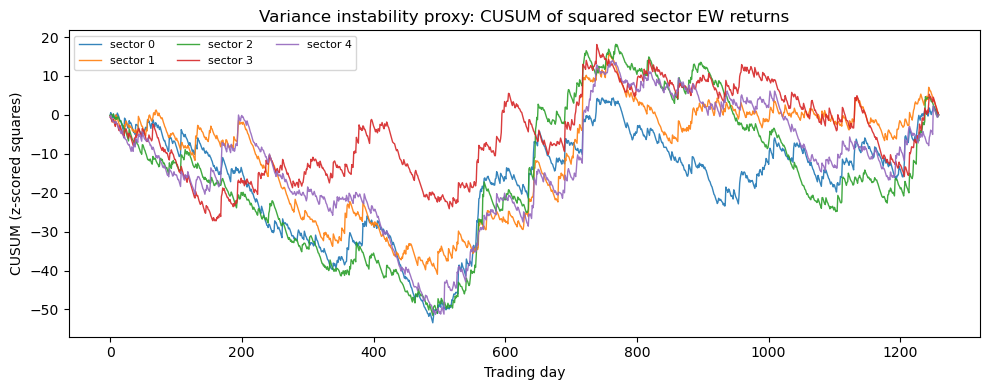

In [34]:
sector_ids = np.asarray(meta.sector_id, dtype=int)
sector_list = sorted(np.unique(sector_ids).tolist())
sector_to_idx = {s: np.where(sector_ids == s)[0] for s in sector_list}

print("Assets per sector:")
for s in sector_list:
    print(f"  sector {s}: {len(sector_to_idx[s])} assets")

h = n_days // 2
sec_rows = []
for s in sector_list:
    idx = sector_to_idx[s]
    R = lr_day[:, idx]
    ew_s = R.mean(axis=1)
    for seg_name, sl in [("1st half", slice(0, h)), ("2nd half", slice(h, None))]:
        e = ew_s[sl]
        sec_rows.append(
            {
                "sector": s,
                "segment": seg_name,
                "n_assets": len(idx),
                "ann_vol_ew": ann_vol(e),
                "ann_Sharpe_ew": ann_sharpe(e),
                "avg_pairwise_corr_within": avg_pairwise_corr(R[sl]),
            }
        )

half_long = pd.DataFrame(sec_rows)
piv_vol = half_long.pivot(index="sector", columns="segment", values="ann_vol_ew")
piv_vol["2nd/1st vol ratio"] = piv_vol["2nd half"] / piv_vol["1st half"]
display(piv_vol.round(4))

piv_corr = half_long.pivot(index="sector", columns="segment", values="avg_pairwise_corr_within")
piv_corr["delta corr (2nd−1st)"] = piv_corr["2nd half"] - piv_corr["1st half"]
display(piv_corr.round(4))

# Monthly ann. vol (EW within sector): heatmap months × sector
dpm = TRADING_DAYS_PER_MONTH
n_months_sec = n_days // dpm
month_sector_vol = np.zeros((n_months_sec, len(sector_list)))
for mi in range(n_months_sec):
    sl = slice(mi * dpm, (mi + 1) * dpm)
    for si, s in enumerate(sector_list):
        idx = sector_to_idx[s]
        r_m = lr_day[sl, idx].mean(axis=1)
        month_sector_vol[mi, si] = ann_vol(r_m)

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(month_sector_vol.T, aspect="auto", interpolation="nearest", cmap="YlOrRd")
ax.set_yticks(range(len(sector_list)), labels=[f"sector {s}" for s in sector_list])
ax.set_xlabel("Month index (21 trading days each)")
ax.set_title("Annualized vol: equal-weight portfolio within each sector")
plt.colorbar(im, ax=ax, shrink=0.85, label="ann. vol")
plt.tight_layout()
plt.show()

# Rolling within-sector average pairwise correlation
ROLL_WIN_S = 63
step_s = 5
fig, ax = plt.subplots(figsize=(10, 4))
for s in sector_list:
    idx = sector_to_idx[s]
    roll_c = []
    mids = []
    for st in range(0, n_days - ROLL_WIN_S + 1, step_s):
        W = lr_day[st : st + ROLL_WIN_S, idx]
        roll_c.append(avg_pairwise_corr(W))
        mids.append(st + ROLL_WIN_S // 2)
    ax.plot(mids, roll_c, lw=1.2, marker=".", ms=2, label=f"sector {s}")
ax.set_xlabel("Trading day (center of window)")
ax.set_ylabel("Avg pairwise corr within sector")
ax.set_title(f"Rolling {ROLL_WIN_S}d: within-sector correlation by sector")
ax.legend(loc="best", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# CUSUM of squared sector EW returns (per sector, z-scored vs full sample of that series)
fig, ax = plt.subplots(figsize=(10, 4))
for s in sector_list:
    idx = sector_to_idx[s]
    ew_s = lr_day[:, idx].mean(axis=1)
    v = ew_s**2
    v_c = (v - v.mean()) / (v.std(ddof=1) + 1e-12)
    ax.plot(np.cumsum(v_c), lw=1.0, label=f"sector {s}", alpha=0.9)
ax.set_xlabel("Trading day")
ax.set_ylabel("CUSUM (z-scored squares)")
ax.set_title("Variance instability proxy: CUSUM of squared sector EW returns")
ax.legend(loc="best", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Rolling windows: average correlation and PCA (1st component share)

Uses **rolling daily windows** (default 63 trading days ≈ 3 months). For each window we compute mean pairwise correlation and, on **standardized** returns, the fraction of variance explained by the first principal component (a simple "marketness" proxy). `step` advances the window by several days so the notebook stays responsive; set `step = 1` for maximum resolution.

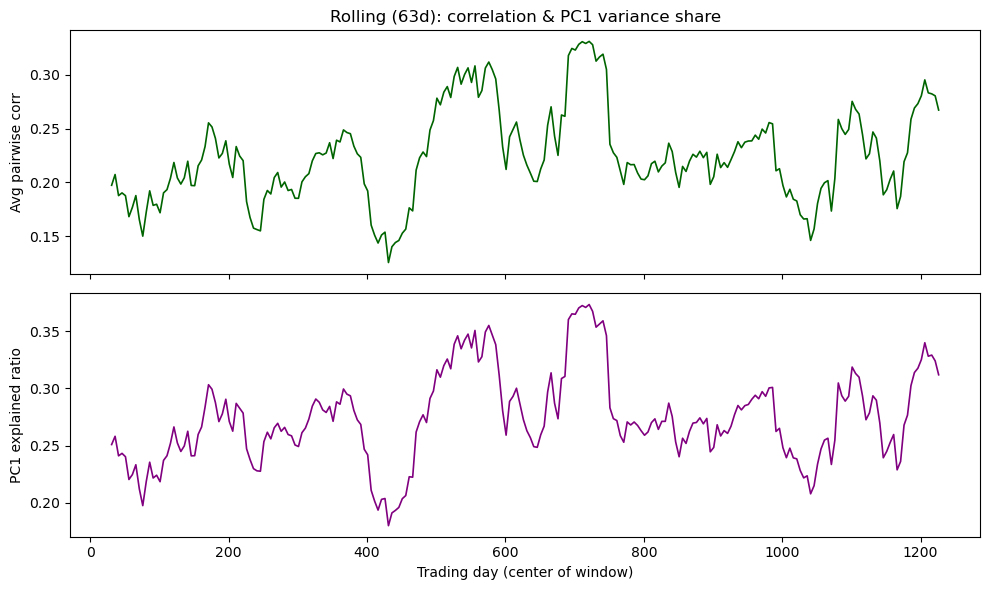

Rolling avg pairwise corr: min 0.1255, max 0.3310, range 0.2055
Rolling PC1 share: min 0.1799, max 0.3735, range 0.1936


In [35]:
ROLL_WIN = 63
step = 5  # set to 1 for daily steps (slower)

starts = range(0, n_days - ROLL_WIN + 1, step)
roll_mid = []
roll_corr = []
roll_pc1 = []

for s in starts:
    W = lr_day[s : s + ROLL_WIN]
    roll_mid.append(s + ROLL_WIN // 2)
    roll_corr.append(avg_pairwise_corr(W))
    Z = StandardScaler().fit_transform(W)
    pca = PCA(n_components=1).fit(Z)
    roll_pc1.append(float(pca.explained_variance_ratio_[0]))

roll_mid = np.array(roll_mid)
roll_corr = np.array(roll_corr)
roll_pc1 = np.array(roll_pc1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(roll_mid, roll_corr, color="darkgreen", lw=1.2)
axes[0].set_ylabel("Avg pairwise corr")
axes[0].set_title(f"Rolling ({ROLL_WIN}d): correlation & PC1 variance share")
axes[1].plot(roll_mid, roll_pc1, color="purple", lw=1.2)
axes[1].set_ylabel("PC1 explained ratio")
axes[1].set_xlabel("Trading day (center of window)")
plt.tight_layout()
plt.show()

print("Rolling avg pairwise corr: min {:.4f}, max {:.4f}, range {:.4f}".format(
    np.nanmin(roll_corr), np.nanmax(roll_corr), np.nanmax(roll_corr) - np.nanmin(roll_corr)
))
print("Rolling PC1 share: min {:.4f}, max {:.4f}, range {:.4f}".format(
    np.nanmin(roll_pc1), np.nanmax(roll_pc1), np.nanmax(roll_pc1) - np.nanmin(roll_pc1)
))

## Covariance stability: Frobenius distance between rolling correlation matrices

Large jumps can indicate a **structure** regime shift (who moves together changed). We use correlation matrices for scale robustness.

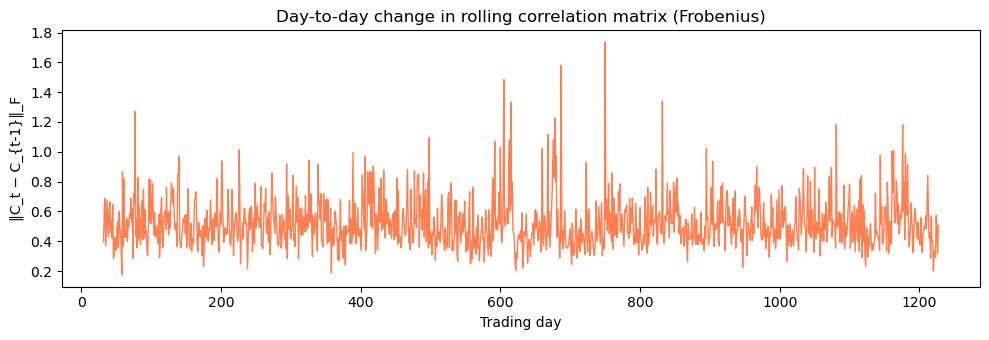

Frobenius step stats: mean=0.5226, max=1.7365


In [36]:
def corr_mat(R: np.ndarray) -> np.ndarray:
    return np.corrcoef(R.T)


CORR_WIN = 63
corr_mats = []
corr_starts = list(range(0, n_days - CORR_WIN + 1))
for s in corr_starts:
    corr_mats.append(corr_mat(lr_day[s : s + CORR_WIN]))

fro_dists = []
for i in range(1, len(corr_mats)):
    D = corr_mats[i] - corr_mats[i - 1]
    fro_dists.append(float(np.linalg.norm(D, ord="fro")))

fro_dists = np.array(fro_dists)
day_idx = np.array(corr_starts[1:]) + CORR_WIN // 2

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(day_idx, fro_dists, color="coral", lw=1.0)
ax.set_xlabel("Trading day")
ax.set_ylabel("‖C_t − C_{t-1}‖_F")
ax.set_title("Day-to-day change in rolling correlation matrix (Frobenius)")
plt.tight_layout()
plt.show()

print(f"Frobenius step stats: mean={fro_dists.mean():.4f}, max={fro_dists.max():.4f}")

## CUSUM of squared EW returns (informal variance instability)

Let $v_t = (r^{\mathrm{ew}}_t)^2$. Standardize $v_t$ and form cumulative sums of deviations from the mean. **Drift** in this path can flag periods where variance is persistently high or low vs the full sample. This is a simple exploratory plot, not a formal test with calibrated thresholds.

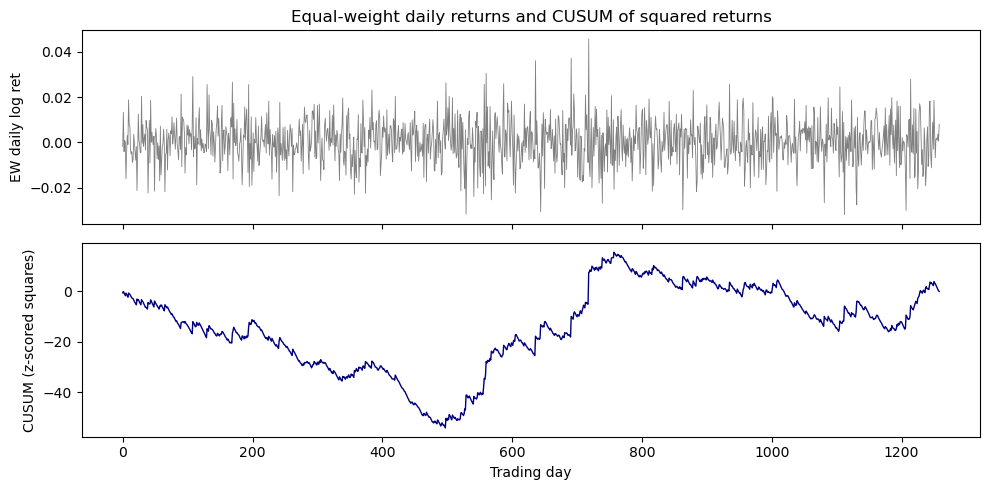

In [37]:
v = ew_daily**2
v_c = (v - v.mean()) / (v.std(ddof=1) + 1e-12)
cusum = np.cumsum(v_c)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(ew_daily, lw=0.6, color="gray")
axes[0].set_ylabel("EW daily log ret")
axes[0].set_title("Equal-weight daily returns and CUSUM of squared returns")
axes[1].plot(cusum, color="navy", lw=1.0)
axes[1].set_ylabel("CUSUM (z-scored squares)")
axes[1].set_xlabel("Trading day")
plt.tight_layout()
plt.show()

## Sliding-month Sharpe: all models in `STRATEGY_REGISTRY`

Same protocol as `months_validate.py` / `compare_strategies_months.py`: train on 24 rolling months, hold out **one** month, repeat for each disjoint holdout month. Each line in the plot is **one strategy**; each point is **that month’s** annualized Sharpe for a **fresh** fitted strategy instance.

This block is **slow** (one run per key in `STRATEGY_REGISTRY` × ~36 holdout months). After adding a strategy in `submission.py`, use **Restart kernel** then **Run all** so Python reloads the registry (otherwise you may still see the old list).

Running 6 strategies × 36 holdout month(s) (same sliding window as months_validate)...

  'baseline'... done (mean Sharpe +0.6720)
  'cost_aware_tilt'... done (mean Sharpe +0.5995)
  'intraday_risk_parity'... done (mean Sharpe +0.6561)
  'momentum_tilt'... done (mean Sharpe +0.6720)
  'risk_parity'... done (mean Sharpe +0.5820)
  'vol_target_risk_parity'... done (mean Sharpe +0.5338)


,mean_Sharpe,std_Sharpe,min_Sharpe,max_Sharpe,n,error
strategy,,,,,,
baseline,0.672049,2.490796,-4.306618,5.614684,36,
cost_aware_tilt,0.599528,2.635875,-5.077363,6.701668,36,
intraday_risk_parity,0.656125,2.417248,-4.375251,4.852181,36,
momentum_tilt,0.672049,2.490796,-4.306618,5.614684,36,
risk_parity,0.582050,2.491264,-4.268353,5.118627,36,
vol_target_risk_parity,0.533826,2.537451,-4.696471,4.993934,36,


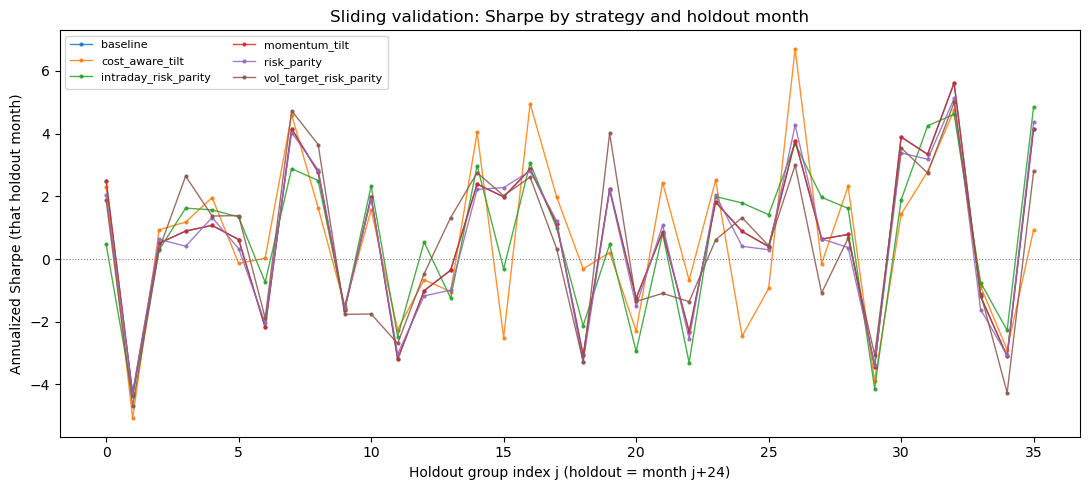

In [38]:
import importlib
import submission as _submission

importlib.reload(_submission)
_reg = _submission.STRATEGY_REGISTRY

strategy_names = sorted(_reg.keys())
print(
    f"STRATEGY_REGISTRY: {len(strategy_names)} strategies —",
    ", ".join(strategy_names),
)
sharpes_by_strategy: dict[str, np.ndarray] = {}
errors: dict[str, str] = {}

_, n_groups, _ = sliding_month_groups_shape(prices)
print(
    f"Running {len(strategy_names)} strategies × {n_groups} holdout month(s) "
    "(same sliding window as months_validate)...\n"
)

for name in strategy_names:
    factory = _reg[name]
    print(f"  {name!r}...", end=" ", flush=True)
    try:
        arr = evaluate_sliding_month_sharpes(prices, meta, factory, verbose=False)
        sharpes_by_strategy[name] = arr
        print(f"done (mean Sharpe {float(np.mean(arr)):+.4f})")
    except Exception as e:
        errors[name] = str(e)
        print(f"FAILED: {e}")

rows = []
for name in strategy_names:
    if name not in sharpes_by_strategy:
        rows.append(
            {
                "strategy": name,
                "mean_Sharpe": np.nan,
                "std_Sharpe": np.nan,
                "min_Sharpe": np.nan,
                "max_Sharpe": np.nan,
                "n": n_groups,
                "error": errors.get(name, ""),
            }
        )
        continue
    a = sharpes_by_strategy[name]
    rows.append(
        {
            "strategy": name,
            "mean_Sharpe": float(np.mean(a)),
            "std_Sharpe": float(np.std(a, ddof=1)) if len(a) >= 2 else np.nan,
            "min_Sharpe": float(np.min(a)),
            "max_Sharpe": float(np.max(a)),
            "n": len(a),
            "error": "",
        }
    )
sr_summary = pd.DataFrame(rows).set_index("strategy")
display(sr_summary)

fig, ax = plt.subplots(figsize=(11, 5))
holdout_idx = np.arange(n_groups)
for name in strategy_names:
    if name not in sharpes_by_strategy:
        continue
    ax.plot(
        holdout_idx,
        sharpes_by_strategy[name],
        marker=".",
        ms=4,
        lw=1,
        label=name,
        alpha=0.85,
    )
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Holdout group index j (holdout = month j+24)")
ax.set_ylabel("Annualized Sharpe (that holdout month)")
ax.set_title("Sliding validation: Sharpe by strategy and holdout month")
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## How to read this

- **Static `meta.csv`** cannot show a regime change; focus on price-derived series.
- **First vs second half** and **monthly vol** show coarse drift in risk.
- **Rolling correlation / PC1 / Frobenius** track **structure** (co-movement) over time.
- **CUSUM on squares** highlights **persistent** vol shifts vs the global average.
- **Per-sector tables and heatmap:** compare **2nd/1st vol ratio** and **delta corr** across sectors—one sector standing out suggests sector-specific drift. The **heatmap** shows whether bad vol months are **global** or **isolated** to one sector. **Rolling within-sector corr** and **per-sector CUSUM** help spot structure/vol shifts **inside** each sector bucket.
- **Sliding Sharpes (all strategies)** show how each **model** scores month by month under the competition backtest (costs, gross limit). Divergence between strategies = different sensitivity; common dips/peaks across strategies often line up with **harder/easier** periods in the **data** (still not a formal break test).

`create_strategy()` in `submission.py` picks the **single** strategy used by `validate.py` / default `months_validate.py`; this notebook runs **every** key in `STRATEGY_REGISTRY` for comparison.

Live competition **regime changes** may still be absent from public data by design.